# Non-LTE Monte Carlo Iterative Solver

This notebook uses the same coma setup as `examples/level_pop.ipynb`, then runs the iterative solver in `problemSolver.py`.

It shows:

1. the reference population-ratio based `J_\nu` profile,
2. the initial two-level coma guess,
3. the evolution of `J_\nu` with outer iteration,
4. the evolution of emergent intensity with outer iteration.


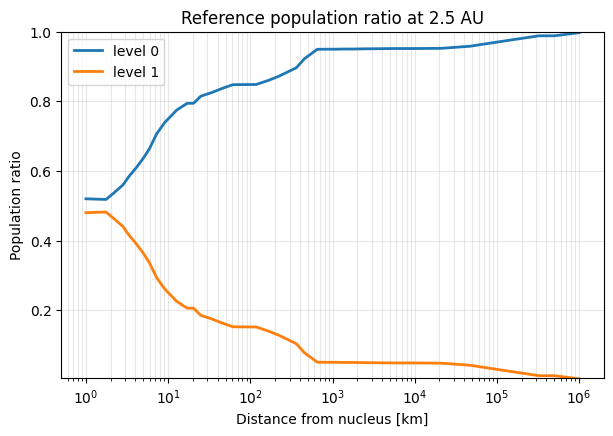

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

data_path = repo_root / "data" / "r_lev0_2.5au.csv"
profile = np.loadtxt(data_path, delimiter=",")

radius_km = profile[::-1, 0]
level0_ratio = profile[::-1, 1] + 0.4 * (1 - profile[::-1, 1])
level1_ratio = 1.0 - level0_ratio

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(radius_km, level0_ratio, lw=2, label="level 0")
ax.semilogx(radius_km, level1_ratio, lw=2, label="level 1")
ax.set_ylim(0.005, 1.0)
ax.set_xlabel("Distance from nucleus [km]")
ax.set_ylabel("Population ratio")
ax.set_title("Reference population ratio at 2.5 AU")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()


In [2]:
from ComaGrid import ComaGrid
from Einstein_coeff import einstein_coeffs_B
from Electron_collision import electron_collision_rate
from Molecular_collision import molecular_collision_rate
from Solar_pumping import scale_g_factors_from_1au
from problemSolver import iterate_two_level_nlte
from profiles import (
    calc_density,
    electron_biver_1997,
    temperature_inverse_distance,
    velocity_tanh,
)

xc = radius_km * 1.0e3
xf = np.empty(xc.size + 1, dtype=np.float64)
xf[1:-1] = np.sqrt(xc[:-1] * xc[1:])
xf[0] = xc[0] ** 2 / xf[1]
xf[-1] = xc[-1] ** 2 / xf[-2]

r_h = 2.5
v0 = 720.0
c_scale = 3.5e3
velocity = velocity_tanh(xc, v0=v0, c=c_scale)

T0 = 10.0
temperature = temperature_inverse_distance(xc, a=7, b=1, t0=T0, r0=2000)

Q = 1.0e26
density = calc_density(
    Q,
    xc,
    velocity,
    r_h=r_h,
    model_type="isotropic",
    photo_dissociation=True,
)

nelec, telec = electron_biver_1997(
    Q,
    r_h=r_h,
    r=xc,
    v=velocity,
    t_kin=temperature,
    t_emax=10000,
)

nu_Hz = 556.936e9
A_ul_s_1 = 3.456e-3
g_u = 9.0
g_l = 9.0
B_ul_SI, B_lu_SI = einstein_coeffs_B(
    nu_Hz=nu_Hz,
    A_ul_s_1=A_ul_s_1,
    g_u=g_u,
    g_l=g_l,
)

fractions_ref = np.zeros((xc.size, 1), dtype=np.float64)
fractions_ref[:, 0] = 1.0 - level0_ratio

coma_ref = ComaGrid(temperature, density, velocity, nelec, telec, fractions_ref)
coma_ref.xf = xf
coma_ref.xc = xc

n_l_ref = coma_ref.density[:, 0]
n_u_ref = coma_ref.density[:, 1]
Cm_ul_s_1 = molecular_collision_rate(density, temperature)
electron_rates = np.array(
    [
        electron_collision_rate(
            n_e,
            t_e,
            nu_Hz=nu_Hz,
            A_ul_s_1=A_ul_s_1,
            g_u=g_u,
            g_l=g_l,
        )
        for n_e, t_e in zip(coma_ref.nelec, coma_ref.telec)
    ],
    dtype=np.float64,
)
Ce_ul_s_1 = electron_rates[:, 0]
Ce_lu_s_1 = electron_rates[:, 1]
G_ul_s_1, G_lu_s_1 = scale_g_factors_from_1au(heliocentric_distance_AU=r_h)
Cm_lu_s_1 = np.zeros_like(xc)

numerator = (
    n_u_ref * (A_ul_s_1 + Cm_ul_s_1 + Ce_ul_s_1 + G_ul_s_1)
    - n_l_ref * (Cm_lu_s_1 + Ce_lu_s_1 + G_lu_s_1)
)
denominator = n_l_ref * B_lu_SI - n_u_ref * B_ul_SI

J_nu_ref = np.full_like(xc, np.nan, dtype=np.float64)
safe = np.abs(denominator) > 0.0
J_nu_ref[safe] = numerator[safe] / denominator[safe]

initial_excited_fraction = np.full((xc.size, 1), 0.1, dtype=np.float64)
coma_iter = ComaGrid(
    temperature=np.array(temperature, dtype=np.float64, copy=True),
    total_number_density=np.array(density, dtype=np.float64, copy=True),
    velocity=np.array(velocity, dtype=np.float64, copy=True),
    nelec=np.array(nelec, dtype=np.float64, copy=True),
    telec=np.array(telec, dtype=np.float64, copy=True),
    fractions=initial_excited_fraction,
)
coma_iter.xf = np.array(xf, dtype=np.float64, copy=True)
coma_iter.xc = np.array(xc, dtype=np.float64, copy=True)

print(f"B_ul = {B_ul_SI:.3e} m^2 J^-1 s^-1")
print(f"B_lu = {B_lu_SI:.3e} m^2 J^-1 s^-1")
print("Initial excited fraction:", float(initial_excited_fraction[0, 0]))


B_ul = 1.357e+12 m^2 J^-1 s^-1
B_lu = 1.357e+12 m^2 J^-1 s^-1
Initial excited fraction: 0.1


In [3]:
result = iterate_two_level_nlte(
    coma_iter,
    heliocentric_distance_AU=r_h,
    lower_level=0,
    upper_level=1,
    nu_Hz=nu_Hz,
    A_ul_s_1=A_ul_s_1,
    g_u=g_u,
    g_l=g_l,
    background_intensity_outer=0.,
    background_intensity_inner=1.0e-12,
    B_ul_SI=B_ul_SI,
    B_lu_SI=B_lu_SI,
    Cm_ul_s_1=Cm_ul_s_1,
    Cm_lu_s_1=Cm_lu_s_1,
    Ce_ul_s_1=Ce_ul_s_1,
    Ce_lu_s_1=Ce_lu_s_1,
    G_ul_s_1=G_ul_s_1,
    G_lu_s_1=G_lu_s_1,
    max_iterations=25,
    j_nu_rtol=1.0e-6,
    j_nu_atol=1.0e-20,
    population_max_iterations=20000,
    population_tolerance=1.0e-10,
    packet_fraction_range=(0.05, 0.35),
    random_seed=42,
)

history = result["history"]
iteration_numbers = np.array([entry["iteration"] for entry in history], dtype=int)
jnu_history = np.array([entry["J_nu"] for entry in history], dtype=np.float64)
n0_history = np.array([entry["n_lower"] for entry in history], dtype=np.float64)
n1_history = np.array([entry["n_upper"] for entry in history], dtype=np.float64)
ratio0_history = n0_history / np.maximum(n0_history + n1_history, np.finfo(np.float64).tiny)
ratio1_history = n1_history / np.maximum(n0_history + n1_history, np.finfo(np.float64).tiny)
emergent_outer = np.array([entry["I_nu_emergent_outer"] for entry in history], dtype=np.float64)
emergent_inner = np.array([entry["I_nu_emergent_inner"] for entry in history], dtype=np.float64)
relative_change = np.array([np.nanmax(entry["relative_change"]) for entry in history], dtype=np.float64)

print("Outer iterations used:", result["iterations_used"])
print("J_nu converged:", result["converged"])
print("Final max relative change:", np.nanmax(result["relative_change"]))


Outer iterations used: 25
J_nu converged: False
Final max relative change: 0.009407427376055873


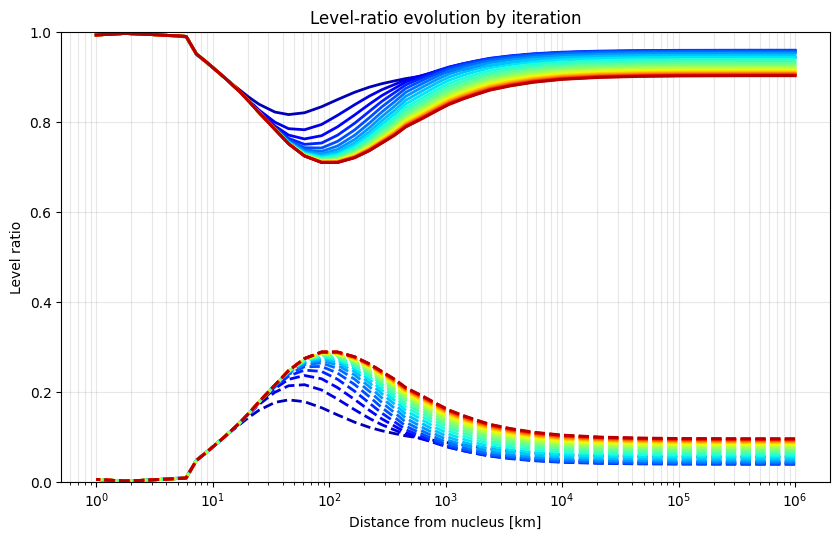

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
r_km = xc * 1.0e-3
colors = plt.cm.jet(np.linspace(0.05, 0.95, len(history)))

for i, color in enumerate(colors):
    iteration_label = f"iter {iteration_numbers[i]}"
    ax.semilogx(r_km, ratio0_history[i], color=color, lw=2, linestyle="-", label=f"rlevel0 {iteration_label}")
    ax.semilogx(r_km, ratio1_history[i], color=color, lw=2, linestyle="--", label=f"rlevel1 {iteration_label}")

ax.set_xlabel("Distance from nucleus [km]")
ax.set_ylabel("Level ratio")
ax.set_title("Level-ratio evolution by iteration")
ax.set_ylim(0.0, 1.0)
ax.grid(True, which="both", alpha=0.3)
# ax.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


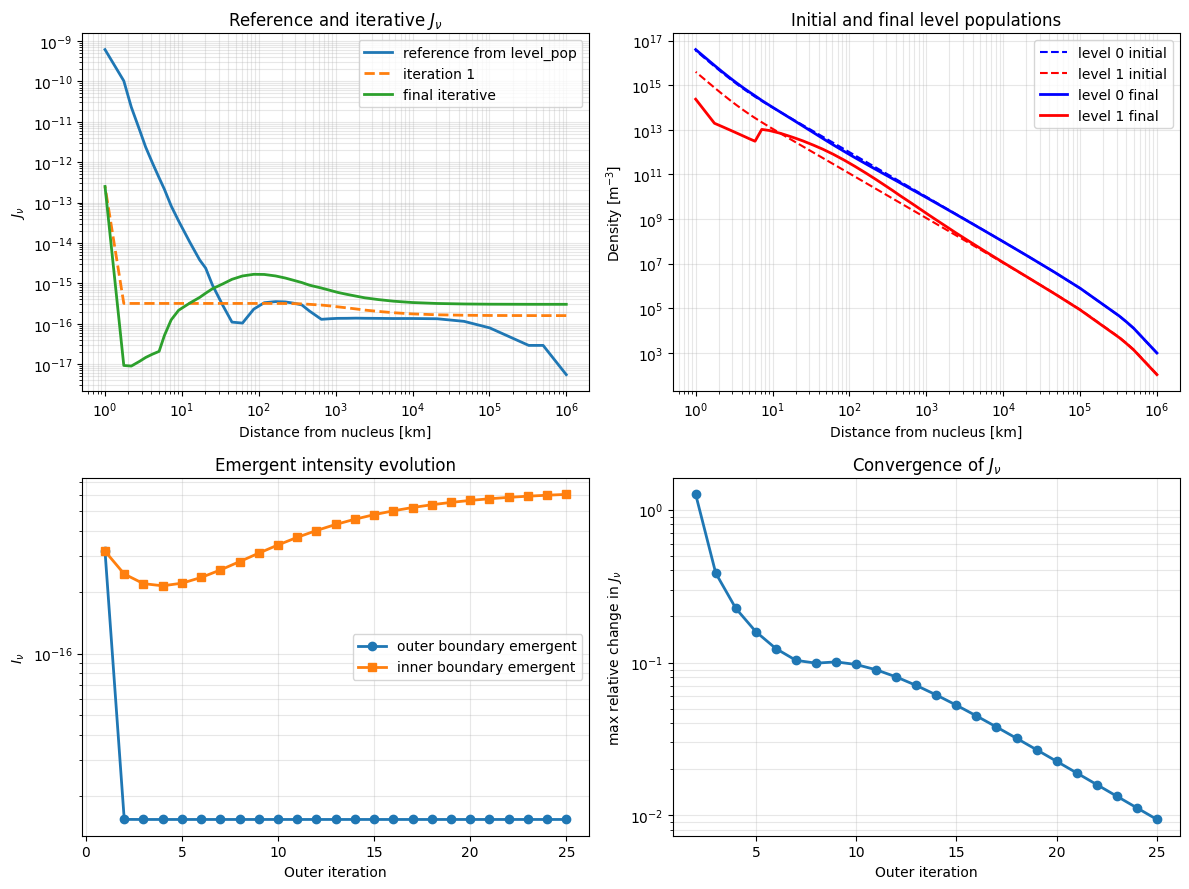

In [5]:
r_km = xc * 1.0e-3
n0_initial = density * (1.0 - initial_excited_fraction[:, 0])
n1_initial = density * initial_excited_fraction[:, 0]
n0_final = result["n_lower"]
n1_final = result["n_upper"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
ax0, ax1, ax2, ax3 = axes.flatten()

ax0.loglog(r_km, J_nu_ref, lw=2, label="reference from level_pop")
ax0.loglog(r_km, jnu_history[0], "--", lw=2, label="iteration 1")
ax0.loglog(r_km, result["J_nu"], lw=2, label="final iterative")
ax0.set_xlabel("Distance from nucleus [km]")
ax0.set_ylabel(r"$J_{\nu}$")
ax0.set_title(r"Reference and iterative $J_{\nu}$")
ax0.grid(True, which="both", alpha=0.3)
ax0.legend()

ax1.loglog(r_km, n0_initial, "b--", lw=1.5, label="level 0 initial")
ax1.loglog(r_km, n1_initial, "r--", lw=1.5, label="level 1 initial")
ax1.loglog(r_km, n0_final, "b-", lw=2, label="level 0 final")
ax1.loglog(r_km, n1_final, "r-", lw=2, label="level 1 final")
ax1.set_xlabel("Distance from nucleus [km]")
ax1.set_ylabel("Density [m$^{-3}$]")
ax1.set_title("Initial and final level populations")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

ax2.semilogy(iteration_numbers, emergent_outer, "o-", lw=2, label="outer boundary emergent")
ax2.semilogy(iteration_numbers, emergent_inner, "s-", lw=2, label="inner boundary emergent")
ax2.set_xlabel("Outer iteration")
ax2.set_ylabel(r"$I_{\nu}$")
ax2.set_title("Emergent intensity evolution")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

ax3.semilogy(iteration_numbers[1:], relative_change[1:], "o-", lw=2)
ax3.set_xlabel("Outer iteration")
ax3.set_ylabel("max relative change in $J_\\nu$")
ax3.set_title(r"Convergence of $J_{\nu}$")
ax3.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


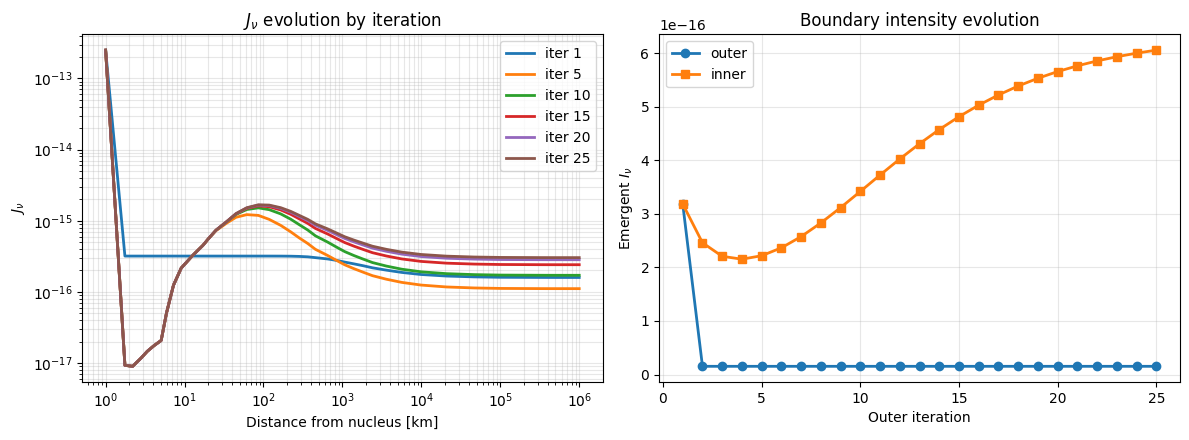

In [9]:
nshow = min(6, len(history))
sample_indices = np.unique(np.linspace(0, len(history) - 1, nshow, dtype=int))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for idx in sample_indices:
    label = f"iter {history[idx]['iteration']}"
    axes[0].loglog(r_km, jnu_history[idx], lw=2, label=label)

axes[0].set_xlabel("Distance from nucleus [km]")
axes[0].set_ylabel(r"$J_{\nu}$")
axes[0].set_title(r"$J_{\nu}$ evolution by iteration")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

axes[1].plot(iteration_numbers, emergent_outer, "o-", lw=2, label="outer")
axes[1].plot(iteration_numbers, emergent_inner, "s-", lw=2, label="inner")
axes[1].set_xlabel("Outer iteration")
axes[1].set_ylabel(r"Emergent $I_{\nu}$")
axes[1].set_title("Boundary intensity evolution")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
